# Sprint 8
## Análisis exploratorio de datos

### Importar archivos

In [2]:
# Importar módulos
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

In [2]:
# Importar archivos
df_companies = pd.read_csv('datasets/moved_project_sql_result_01.csv')
df_neighborhoods = pd.read_csv('datasets/moved_project_sql_result_04.csv')
df_trips_weather = pd.read_csv('datasets/moved_project_sql_result_07.csv')

### Estudiar los datos
#### Empresas de taxis

In [3]:
print("Información general:")
print(df_companies.info())

print("\nDimensiones del DataFrame:")
print(f"Filas: {df_companies.shape[0]}, Columnas: {df_companies.shape[1]}")

Información general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   company_name  64 non-null     object
 1   trips_amount  64 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 1.1+ KB
None

Dimensiones del DataFrame:
Filas: 64, Columnas: 2


In [4]:
print("\nTipos de datos:")
print(df_companies.dtypes)

print("\nPrimeras 5 filas:")
print(df_companies.head())

print("\nÚltimas 5 filas:")
print(df_companies.tail())


Tipos de datos:
company_name    object
trips_amount     int64
dtype: object

Primeras 5 filas:
                      company_name  trips_amount
0                        Flash Cab         19558
1        Taxi Affiliation Services         11422
2                 Medallion Leasin         10367
3                       Yellow Cab          9888
4  Taxi Affiliation Service Yellow          9299

Últimas 5 filas:
                                 company_name  trips_amount
59               4053 - 40193 Adwar H. Nikola             7
60                    2733 - 74600 Benny Jona             7
61              5874 - 73628 Sergey Cab Corp.             5
62  2241 - 44667 - Felman Corp, Manuel Alonso             3
63                3556 - 36214 RC Andrews Cab             2


In [5]:
print("\nEstadísticas descriptivas:")
print(df_companies.describe())

print("\nValores únicos por columna:")
for col in df_companies.columns:
    print(f"{col}: {df_companies[col].nunique()} valores únicos")

print("\nValores nulos:")
print(df_companies.isnull().sum())


Estadísticas descriptivas:
       trips_amount
count     64.000000
mean    2145.484375
std     3812.310186
min        2.000000
25%       20.750000
50%      178.500000
75%     2106.500000
max    19558.000000

Valores únicos por columna:
company_name: 64 valores únicos
trips_amount: 56 valores únicos

Valores nulos:
company_name    0
trips_amount    0
dtype: int64


#### Barrios

In [6]:
print("Información general:")
print(df_neighborhoods.info())

print("\nDimensiones del DataFrame:")
print(f"Filas: {df_neighborhoods.shape[0]}, Columnas: {df_neighborhoods.shape[1]}")

Información general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94 entries, 0 to 93
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   dropoff_location_name  94 non-null     object 
 1   average_trips          94 non-null     float64
dtypes: float64(1), object(1)
memory usage: 1.6+ KB
None

Dimensiones del DataFrame:
Filas: 94, Columnas: 2


In [7]:
print("\nTipos de datos:")
print(df_neighborhoods.dtypes)

print("\nPrimeras 5 filas:")
print(df_neighborhoods.head())

print("\nÚltimas 5 filas:")
print(df_neighborhoods.tail())


Tipos de datos:
dropoff_location_name     object
average_trips            float64
dtype: object

Primeras 5 filas:
  dropoff_location_name  average_trips
0                  Loop   10727.466667
1           River North    9523.666667
2         Streeterville    6664.666667
3             West Loop    5163.666667
4                O'Hare    2546.900000

Últimas 5 filas:
   dropoff_location_name  average_trips
89       Mount Greenwood       3.137931
90             Hegewisch       3.117647
91              Burnside       2.333333
92             East Side       1.961538
93             Riverdale       1.800000


In [8]:
print("\nEstadísticas descriptivas:")
print(df_neighborhoods.describe())

print("\nValores únicos por columna:")
for col in df_neighborhoods.columns:
    print(f"{col}: {df_neighborhoods[col].nunique()} valores únicos")

print("\nValores nulos:")
print(df_neighborhoods.isnull().sum())


Estadísticas descriptivas:
       average_trips
count      94.000000
mean      599.953728
std      1714.591098
min         1.800000
25%        14.266667
50%        52.016667
75%       298.858333
max     10727.466667

Valores únicos por columna:
dropoff_location_name: 94 valores únicos
average_trips: 94 valores únicos

Valores nulos:
dropoff_location_name    0
average_trips            0
dtype: int64


In [9]:
# RESUMEN GENERAL
print("\n\n📋 RESUMEN GENERAL")
print("=" * 50)
print(f"Total de empresas de taxis: {len(df_companies)}")
print(f"Total de viajes (15-16 Nov): {df_companies['trips_amount'].sum():,}")



📋 RESUMEN GENERAL
Total de empresas de taxis: 64
Total de viajes (15-16 Nov): 137,311


### Verificar que los tipos de datos sean correctos

In [10]:
print("📊 Tipos de datos actuales:")
print(df_companies.dtypes)
print()
print(df_neighborhoods.dtypes)

📊 Tipos de datos actuales:
company_name    object
trips_amount     int64
dtype: object

dropoff_location_name     object
average_trips            float64
dtype: object


Los tipos de datos parecen ser correctos y correspondientes a los datos que se pueden ver dentro de los DataFrames.

### Identificar los 10 principales barrios en términos de finalización del recorrido

In [11]:
# IDENTIFICAR TOP 10 BARRIOS POR FINALIZACIONES
print("🏆 TOP 10 BARRIOS POR FINALIZACIONES")
print("=" * 50)

# Ordenar por average_trips en orden descendente y tomar los primeros 10
top_10_neighborhoods = df_neighborhoods.sort_values('average_trips', ascending=False).head(10)

print("Los 10 principales barrios por número de finalizaciones:")
print(top_10_neighborhoods)

print(f"\n📊 ANÁLISIS:")
print(f"Barrio líder: {top_10_neighborhoods.iloc[0]['dropoff_location_name']} con {top_10_neighborhoods.iloc[0]['average_trips']:.1f} viajes promedio")
print(f"Diferencia con el 2º lugar: {top_10_neighborhoods.iloc[0]['average_trips'] - top_10_neighborhoods.iloc[1]['average_trips']:.1f} viajes")
print(f"Barrio en 10º lugar: {top_10_neighborhoods.iloc[9]['dropoff_location_name']} con {top_10_neighborhoods.iloc[9]['average_trips']:.1f} viajes promedio")

🏆 TOP 10 BARRIOS POR FINALIZACIONES
Los 10 principales barrios por número de finalizaciones:
  dropoff_location_name  average_trips
0                  Loop   10727.466667
1           River North    9523.666667
2         Streeterville    6664.666667
3             West Loop    5163.666667
4                O'Hare    2546.900000
5             Lake View    2420.966667
6            Grant Park    2068.533333
7         Museum Campus    1510.000000
8            Gold Coast    1364.233333
9    Sheffield & DePaul    1259.766667

📊 ANÁLISIS:
Barrio líder: Loop con 10727.5 viajes promedio
Diferencia con el 2º lugar: 1203.8 viajes
Barrio en 10º lugar: Sheffield & DePaul con 1259.8 viajes promedio


### Hacer gráficos:
- Empresas de taxis y número de viajes
- Los 10 barrios principales por número de finalizaciones.

Creando gráfico 1: Empresas de taxis...
Creando gráfico 2: Top 10 barrios...


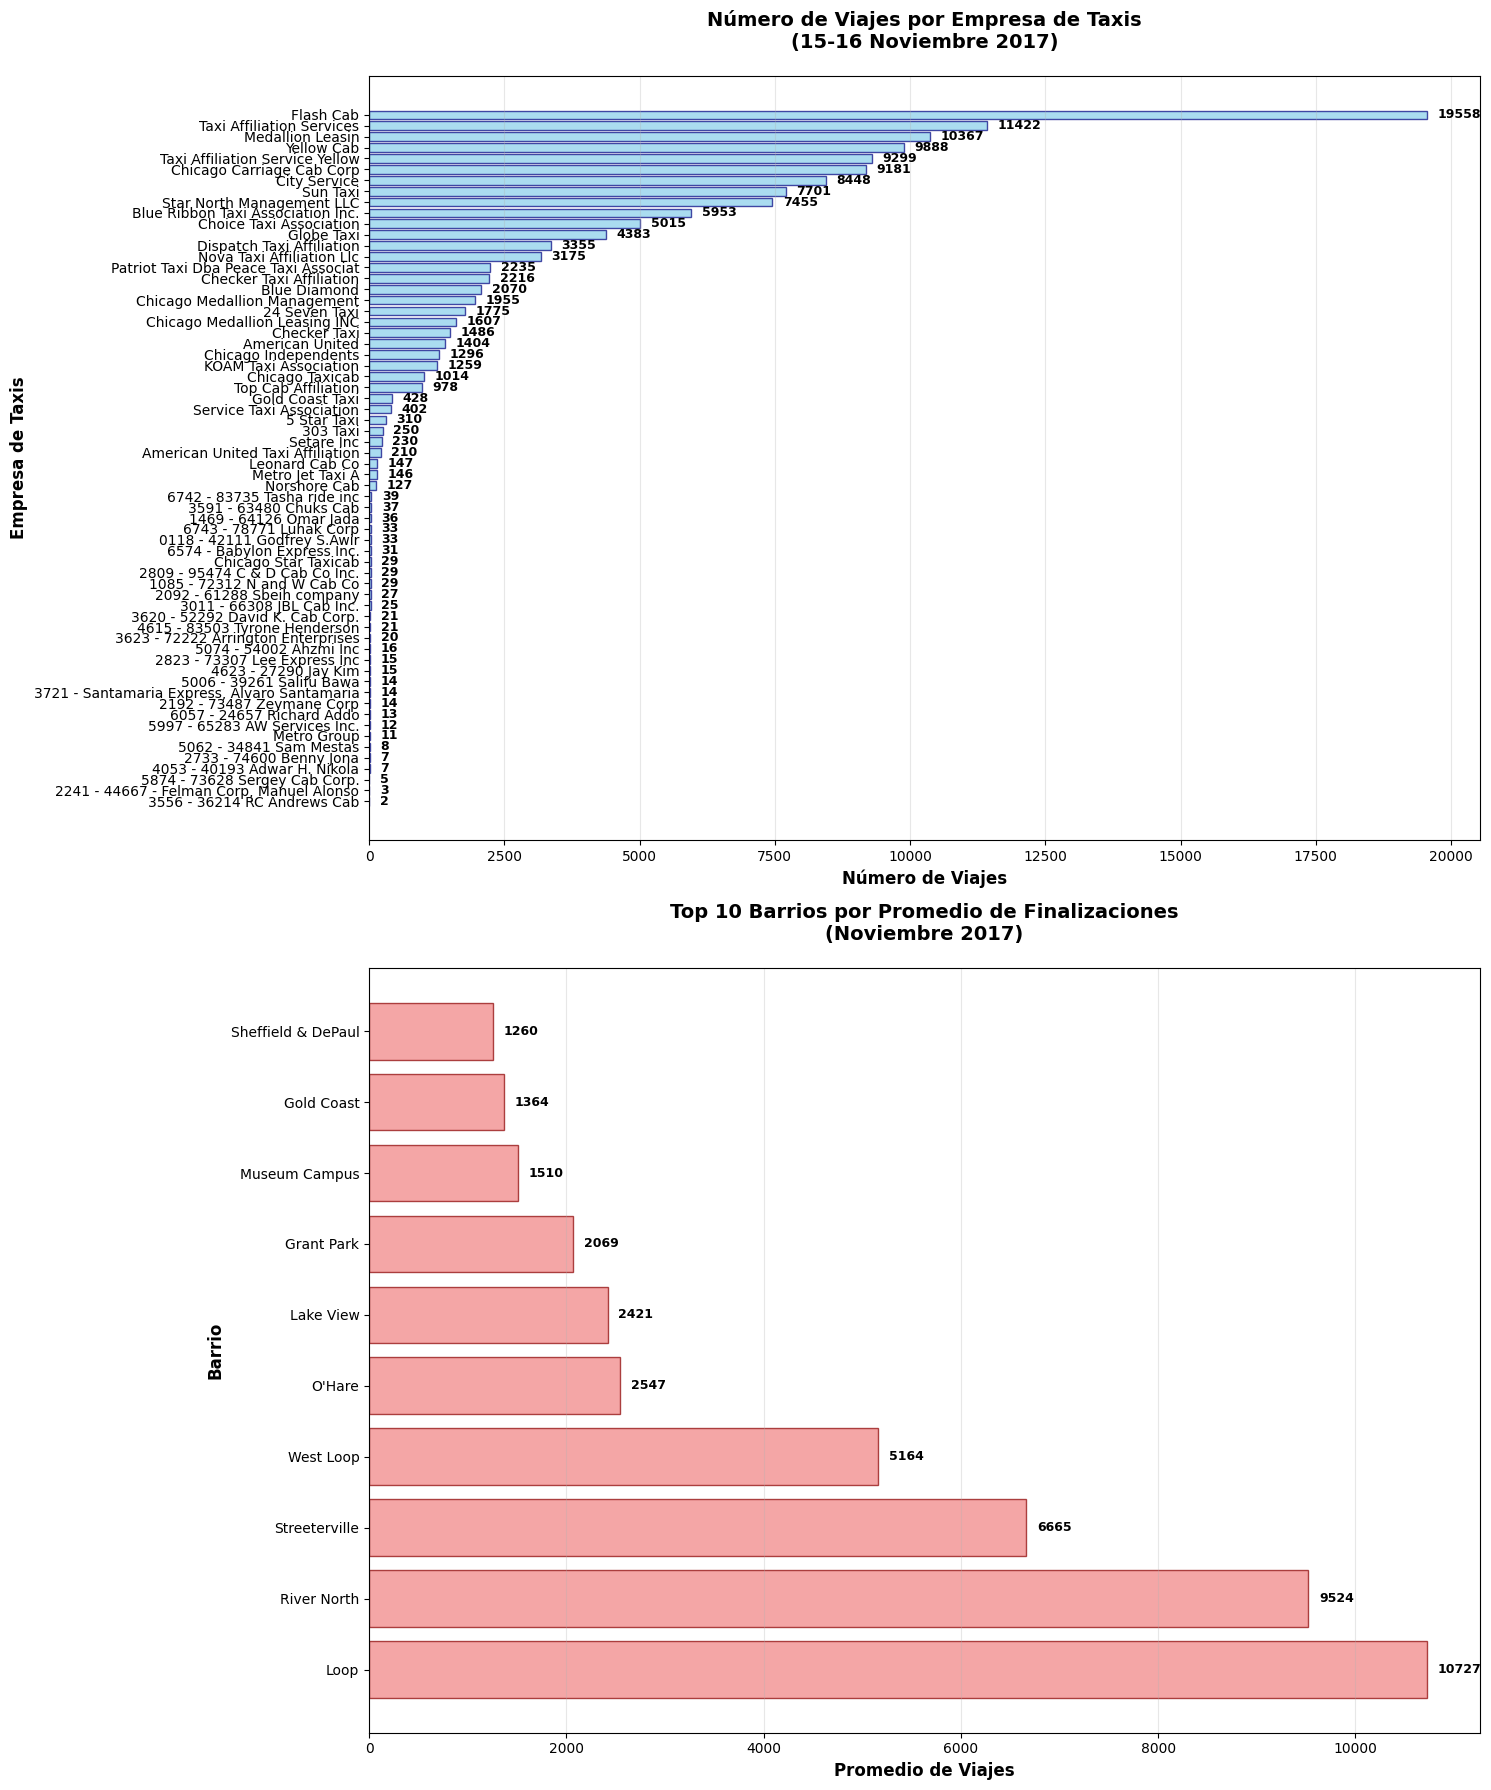

✅ Gráficos creados exitosamente


In [12]:
# Configurar estilo
plt.style.use('default')
sns.set_palette("husl")

# Crear figura con subplots
fig, axes = plt.subplots(2, 1, figsize=(15, 18))

# GRÁFICO 1: Empresas de taxis y número de viajes
print("Creando gráfico 1: Empresas de taxis...")

# Ordenar empresas por número de viajes (de menor a mayor para barras horizontales)
companies_sorted = df_companies.sort_values('trips_amount', ascending=True)

bars1 = axes[0].barh(companies_sorted['company_name'], 
                     companies_sorted['trips_amount'], 
                     color='skyblue', 
                     edgecolor='navy', 
                     alpha=0.7)

axes[0].set_xlabel('Número de Viajes', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Empresa de Taxis', fontsize=12, fontweight='bold')
axes[0].set_title('Número de Viajes por Empresa de Taxis\n(15-16 Noviembre 2017)', 
                  fontsize=14, fontweight='bold', pad=20)
axes[0].grid(axis='x', alpha=0.3)

# Añadir valores en las barras
for bar in bars1:
    width = bar.get_width()
    axes[0].text(width + 0.01 * max(companies_sorted['trips_amount']), 
                 bar.get_y() + bar.get_height()/2, 
                 f'{int(width)}', ha='left', va='center', fontweight='bold', fontsize=9)

# GRÁFICO 2: Top 10 barrios por finalizaciones
print("Creando gráfico 2: Top 10 barrios...")

bars2 = axes[1].barh(top_10_neighborhoods['dropoff_location_name'], 
                     top_10_neighborhoods['average_trips'],
                     color='lightcoral', 
                     edgecolor='darkred', 
                     alpha=0.7)

axes[1].set_xlabel('Promedio de Viajes', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Barrio', fontsize=12, fontweight='bold')
axes[1].set_title('Top 10 Barrios por Promedio de Finalizaciones\n(Noviembre 2017)', 
                  fontsize=14, fontweight='bold', pad=20)
axes[1].grid(axis='x', alpha=0.3)

# Añadir valores en las barras
for bar in bars2:
    width = bar.get_width()
    axes[1].text(width + 0.01 * max(top_10_neighborhoods['average_trips']), 
                 bar.get_y() + bar.get_height()/2, 
                 f'{width:.0f}', ha='left', va='center', fontweight='bold', fontsize=9)

# Ajustar layout y mostrar
plt.tight_layout()
plt.show()

print("✅ Gráficos creados exitosamente")

### Conclusiones basadas en cada gráfico y explicar los resultados
#### Primera gráfica
Con respecto al dominio del mercado es claro que "Flash Cab" es el líder indiscutible con **casi** 20,000 viajes. Este primero con una diferencia significativa entre los siguientes puestos que son "Taxi Affiliation" (con 11,422 viajes) y "Medallion Leasin" (con 10,367 viajes).

Con respecto a concentraciones se puede apreciar que la mayoría del mercado es abarcado por los primeros 15 empresas top, después de esos se distribuye más entre otras empresas.

Existen muchas empresas pequeñas, la mayoría con menos de 1,000 viajes, hay una 'cola larga' de operadores pequeños e independientes.

#### Segunda gráfica
Con respecto a dominio geográfico y financiero se puede apreciar claramente que el barrio con mayor promedio es "Loop" con 10,727 viajes. Seguido bastante cerca con "River North" (con 9,524 viajes) y "Streeterville" (con 6,665 viajes).

Sobre patrones en demanda se puede apreciar que los 4 barrios top en viajes tienen una concentración de actividad significativamente concentrada en comparación a los demás barrios, a partir del cuarto la distribución deja de ser tan concentrada.

## Pruebas de hipótesis
### "La duración promedio de los viajes desde el Loop hasta el Aeropuerto Internacional O'Hare cambia los sábados lluviosos".

Explicar:
- Cómo planteaste las hipótesis nula y alternativa.
- Qué criterio usaste para probar las hipótesis y por qué.

In [13]:
# 1. EXPLORAR LOS DATOS
print("\n1️⃣ EXPLORACIÓN DE DATOS")
print("-" * 30)

print("Información del dataset:")
print(df_trips_weather.info())

print("\nDistribución de condiciones climáticas:")
weather_counts = df_trips_weather['weather_conditions'].value_counts()
print(weather_counts)

print(f"\nTotal de viajes: {len(df_trips_weather)}")
print(f"Viajes con buen clima: {weather_counts.get('Good', 0)}")
print(f"Viajes con mal clima: {weather_counts.get('Bad', 0)}")


1️⃣ EXPLORACIÓN DE DATOS
------------------------------
Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1068 entries, 0 to 1067
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   start_ts            1068 non-null   object 
 1   weather_conditions  1068 non-null   object 
 2   duration_seconds    1068 non-null   float64
dtypes: float64(1), object(2)
memory usage: 25.2+ KB
None

Distribución de condiciones climáticas:
weather_conditions
Good    888
Bad     180
Name: count, dtype: int64

Total de viajes: 1068
Viajes con buen clima: 888
Viajes con mal clima: 180


In [14]:
# 2. SEPARAR LOS DATOS POR CONDICIÓN CLIMÁTICA
print("\n2️⃣ SEPARACIÓN DE DATOS POR CLIMA")
print("-" * 40)

# Separar duraciones por condición climática
good_weather_trips = df_trips_weather[df_trips_weather['weather_conditions'] == 'Good']['duration_seconds']
bad_weather_trips = df_trips_weather[df_trips_weather['weather_conditions'] == 'Bad']['duration_seconds']

print("Estadísticas - Buen clima:")
print(f"  Cantidad: {len(good_weather_trips)}")
print(f"  Promedio: {good_weather_trips.mean():.2f} segundos ({good_weather_trips.mean()/60:.2f} minutos)")
print(f"  Mediana: {good_weather_trips.median():.2f} segundos")
print(f"  Desv. estándar: {good_weather_trips.std():.2f} segundos")

print("\nEstadísticas - Mal clima:")
print(f"  Cantidad: {len(bad_weather_trips)}")
print(f"  Promedio: {bad_weather_trips.mean():.2f} segundos ({bad_weather_trips.mean()/60:.2f} minutos)")
print(f"  Mediana: {bad_weather_trips.median():.2f} segundos")
print(f"  Desv. estándar: {bad_weather_trips.std():.2f} segundos")


2️⃣ SEPARACIÓN DE DATOS POR CLIMA
----------------------------------------
Estadísticas - Buen clima:
  Cantidad: 888
  Promedio: 1999.68 segundos (33.33 minutos)
  Mediana: 1800.00 segundos
  Desv. estándar: 759.20 segundos

Estadísticas - Mal clima:
  Cantidad: 180
  Promedio: 2427.21 segundos (40.45 minutos)
  Mediana: 2540.00 segundos
  Desv. estándar: 721.31 segundos


In [15]:
# 3. PLANTEAMIENTO DE HIPÓTESIS
print("\n3️⃣ PLANTEAMIENTO DE HIPÓTESIS")
print("-" * 40)

print("🔬 HIPÓTESIS NULA (H₀):")
print("La duración promedio de los viajes es IGUAL en días de buen clima y mal clima")
print("H₀: μ_good = μ_bad")
print()
print("🔬 HIPÓTESIS ALTERNATIVA (H₁):")
print("La duración promedio de los viajes es DIFERENTE en días de buen clima y mal clima")
print("H₁: μ_good ≠ μ_bad")
print()
print("📊 TIPO DE PRUEBA: Prueba bilateral (two-tailed)")
print("🎯 NIVEL DE SIGNIFICACIÓN: α = 0.05")


3️⃣ PLANTEAMIENTO DE HIPÓTESIS
----------------------------------------
🔬 HIPÓTESIS NULA (H₀):
La duración promedio de los viajes es IGUAL en días de buen clima y mal clima
H₀: μ_good = μ_bad

🔬 HIPÓTESIS ALTERNATIVA (H₁):
La duración promedio de los viajes es DIFERENTE en días de buen clima y mal clima
H₁: μ_good ≠ μ_bad

📊 TIPO DE PRUEBA: Prueba bilateral (two-tailed)
🎯 NIVEL DE SIGNIFICACIÓN: α = 0.05


In [16]:
# 4. VERIFICAR CONDICIONES PARA LA PRUEBA
print("\n4️⃣ VERIFICACIÓN DE CONDICIONES")
print("-" * 40)

print("✅ CONDICIONES NECESARIAS:")
print(f"1. Independencia: Los viajes son eventos independientes ✓")
print(f"2. Tamaño muestral - Buen clima: {len(good_weather_trips)} (>30) ✓")
print(f"3. Tamaño muestral - Mal clima: {len(bad_weather_trips)} (>30 recomendado)")

if len(bad_weather_trips) < 30:
    print("   ⚠️ ADVERTENCIA: Muestra de mal clima es pequeña (<30)")
    print("   Consideraremos usar prueba t de Student")


4️⃣ VERIFICACIÓN DE CONDICIONES
----------------------------------------
✅ CONDICIONES NECESARIAS:
1. Independencia: Los viajes son eventos independientes ✓
2. Tamaño muestral - Buen clima: 888 (>30) ✓
3. Tamaño muestral - Mal clima: 180 (>30 recomendado)
